In [1]:
import numpy as np
import matplotlib.pyplot as plt
from gdr3bcg.bcg import BolometryTable
import pandas as pd
import sympy as sp
from sympy import symbols, diff, log, Float
from astropy.io import fits
import pickle
import ast
#import seaborn as sns
#from matplotlib.ticker import LogLocator, NullFormatter, ScalarFormatter

/home/horvath-zsoka/py312_env/lib/python3.12/site-packages/gdr3bcg/bcg.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


# Correction factors

## Load APOKASC

In [8]:
apo_loc='APOKASC_cat_v7.4.0.fits'
hdu=fits.open(apo_loc)
#print(hdu.info())

apokasc=hdu[1].data
#print(apokasc.columns.names)

# APOKASC stellar parameters
numax_apo = apokasc["APOKASC3_NU_MAX"]
dnu_apo = apokasc["APOKASC3_DELTA_NU"]
Teff_apo = apokasc["APOKASC3_TEFF"]
logg_apo = apokasc["APOKASC3_LOGG"]

## Functions of correction factors: $f_{\Delta\nu}^\mathrm{APO}$, $f_{\nu_\mathrm{max}}^\mathrm{APO}$, $F_\mathrm{raw}, F_\mathrm{adj}$

In [58]:
def corr_polinom(row, method):
    """
    Cao et al. cubic functions.
    method: 'apokasc','raw' or 'adjusted'
    """
    numax=row['numax']
    coeffs_raw=(0.0061,-0.0465, 0.0809,0.0251)
    coeffs_adj=(0.0079, -0.0590, 0.1003, 0.0324)
    coeffs_apokasc=(-0.00556347,0.04268084,-0.07452754,-0.02442568)
    
    match method:
        case 'apokasc':
            a,b,c,d=coeffs_apokasc
        case 'raw':
            a,b,c,d=coeffs_raw
        case 'adjusted':
            a,b,c,d=coeffs_adj
        case _:
            raise ValueError(f"Use 'apokasc', 'raw' or 'adjusted'.")
            
    return (1+a*(np.log(numax))**3+b*(np.log(numax))**2+c*(np.log(numax))+d)**(-1)
    
def get_corrfactors(row):
    """
    Get APOKASC correction factors derived for our targets.
    levels: (nnumax, ndnu, nTeff, nlogg) the sigma levels
    """
    
    levels = row['sigma_levels']

    # levels to tuple format
    if isinstance(levels, str):
        try:
            levels = ast.literal_eval(levels)
        except (ValueError, SyntaxError):
            return None 
            
    if not isinstance(levels, (list, tuple)) or len(levels) != 4:
        return None
        
    nnumax, ndnu, nTeff, nlogg=levels
    
    numax, e_numax = row['numax'],row['e_numax']
    dnu, e_dnu = row['dnu'],row['e_dnu']
    Teff, e_Teff = row['T_eff'],row['e_T_eff']
    logg, e_logg = row['log_g'],row['e_log_g']
    
    print(f'Stellar parameters of target: {row['name']}') 
    print(f'numax: {numax}, deltanu: {dnu}, Teff: {Teff}, logg: {logg}\n')
    
    # Relative uncertainties:
    delta_numax = e_numax/numax
    delta_dnu = e_dnu/dnu
    delta_Teff = e_Teff/Teff
    delta_logg = e_logg/logg
    
    # Sigma level:
    sigma_numax = delta_numax*nnumax
    sigma_dnu = delta_dnu*ndnu
    sigma_Teff = delta_Teff*nTeff
    sigma_logg = delta_logg*nlogg

    # Creating masks for stellar parameters:
    mask_numax=(numax_apo>(numax*(1-sigma_numax)))&(numax_apo<(numax*(1+sigma_numax)))
    mask_dnu=(dnu_apo>(dnu*(1-sigma_dnu)))&(dnu_apo<(dnu*(1+sigma_dnu)))
    mask_Teff=(Teff_apo>(Teff*(1-sigma_Teff)))&(Teff_apo<(Teff*(1+sigma_Teff)))
    mask_logg=(logg_apo>(logg*(1-sigma_logg)))&(logg_apo<(logg*(1+sigma_logg)))
    
    mask=mask_numax & mask_dnu & mask_Teff & mask_logg

    # APOKASC samples result:
    result=apokasc[mask]
    
    if len(result)==0:
        print('No star found in the APOKASC catalog matching the criteria.')
        return None
        
    print(f"Found {len(result)} APOKASC sample with the following sigma levels:\n")
    print(f"""Sigma levels (%):\nnumax: {100*sigma_numax:.4f}\ndeltanu: {100*sigma_dnu:.4f}\nTeff: {100*sigma_Teff:.4f}\nlogg: {100*sigma_logg:.4f}\n""")
    print('APOKASC samples:')
    
    print(f"""
    numax:\n{result['APOKASC3_NU_MAX']},
    delatnu:\n{result['APOKASC3_DELTA_NU']},
    Teff:\n{result['APOKASC3_TEFF']},
    logg:\n{result['APOKASC3_LOGG']},
    f_dnu_apo:\n{result['APOKASC3_F_DELTA_NU']}""") 
    print('---------------------------------------------------------------------\n')

    # Calculate all of the correction factors:
    fdnu=float(np.median(result['APOKASC3_F_DELTA_NU']))
    e_fdnu=float(np.std(result['APOKASC3_F_DELTA_NU']))
    fnumax=corr_polinom(row, method='apokasc')
    Fraw=corr_polinom(row, method='raw')
    Fadj=corr_polinom(row, method='adjusted')

    results={
        'fdnu_apo':fdnu,
        'e_fdnu_apo': e_fdnu,
        'fnumax_apo':fnumax,
        'Fraw':Fraw,
        'Fadj':Fadj
    }

    return results

# Calculating masses

## Functions

### Get $\mathrm{BC}_G$

In [10]:
def get_BC_G(row):
    """
    Deriving bolometric correction in G band (BC_G) with Creevey et al. (2023).
    We approximate the alpha/Fe value as zero.

    T_eff: effective temperature
    Fe/H: [Fe/H]
    alphaFe: [alpha/Fe]
    """
    T_eff, logg, Fe_H, alpha_Fe= row['T_eff'],row['log_g'],row['[Fe/H]'],row['[alpha/Fe]']
    table=BolometryTable()
    BC_G=table.computeBc([T_eff, logg, Fe_H, alpha_Fe])
    return BC_G

###  Get $M_\mathrm{orig}, M_\mathrm{APO}, M_\mathrm{raw}, M_\mathrm{adj}$ 

In [57]:
def get_masses_orig(row):
    """
    Calculating original seismic masses using the four scaling relations without correction factors. 
    Use with "apply" on a pandas dataframe.
    
    row: row of a pandas dataframe
    numax: [uHz]
    dnu: [uHz]
    """
    
    v_BC_G, e_BC_G=row['BC_G'],row['e_BC_G'] 
    v_G, e_G=row['G'],row['e_G']
    v_A_G, e_A_G=row['A_G'],row['e_A_G']
    v_plx, e_plx=row['plx'],row['e_plx']
    v_T_eff, e_T_eff=row['T_eff'],row['e_T_eff']
    v_numax, e_numax=row['numax'],row['e_numax']
    v_dnu, e_dnu=row['dnu'],row['e_dnu']
    
    # References
    numax_S=3090
    dnu_S=135.1
    T_eff_S=5772
    
    # For sympy
    BC_G, G, A_G, plx, T_eff, numax, dnu =symbols('BC_G A_G G plx T_eff numax dnu')

    # Get luminosity
    M_bol_S=4.74
    d=1/plx
    M_G=G+5-5*sp.log(d,10)-A_G
    M_bol=M_G+BC_G
    L_L_S=10**((M_bol_S-M_bol)*0.4)

    # Get masses
    M_M_S1=(numax/numax_S)**3*(dnu/dnu_S)**(-4)*(T_eff/T_eff_S)**(3/2)
    M_M_S2=(dnu/dnu_S)**2*(L_L_S)**(3/2)*(T_eff/T_eff_S)**(-6)
    M_M_S3=(numax/numax_S)*(L_L_S)*(T_eff/T_eff_S)**(-3.5)
    M_M_S4=(numax/numax_S)**(12/5)*(dnu/dnu_S)**(-14/5)*(L_L_S)**(3/10)

    # Get uncertainties
    M_M_S=[]
    e_M_M_S=[]
    
    for j in [M_M_S1, M_M_S2,M_M_S3,M_M_S4]:
        
        partials=[]
        for i in [BC_G, G, A_G, plx, T_eff, numax, dnu]:
            partials.append(diff(j, i))
        
        errors=[e_BC_G, e_G, e_A_G, e_plx, e_T_eff, e_numax, e_dnu]  
        
        count=0
        for i in range(len(partials)):
            count+=(partials[i]*errors[i])**2

        err_mass=count**0.5

        # evalf with actual values:
        e_M_M_S.append(err_mass.evalf(3,subs={BC_G: v_BC_G, G: v_G, A_G:v_A_G, 
                                              plx: v_plx, T_eff:v_T_eff, numax: v_numax,dnu: v_dnu}))
        M_M_S.append(j.evalf(3,subs={BC_G: v_BC_G, G: v_G, A_G:v_A_G, 
                                              plx: v_plx, T_eff:v_T_eff, numax: v_numax,dnu: v_dnu}))

    e_M_M_S = [float(x) for x in e_M_M_S]
    M_M_S = [float(x) for x in M_M_S]

    results={
        'values': M_M_S,
        'errors': e_M_M_S
    }    
    return results

def get_masses_apo(row):
    """
    Calculating APOKASC seismic masses using the four scaling relations.
    Use with "apply" on a pandas dataframe.
    
    row: row of a pandas dataframe
    numax: [uHz]
    dnu: [uHz]
    """
    
    v_BC_G, e_BC_G=row['BC_G'],row['e_BC_G'] 
    v_G, e_G=row['G'],row['e_G']
    v_A_G, e_A_G=row['A_G'],row['e_A_G']
    v_plx, e_plx=row['plx'],row['e_plx']
    v_T_eff, e_T_eff=row['T_eff'],row['e_T_eff']
    v_numax, e_numax=row['numax'],row['e_numax']
    v_dnu, e_dnu=row['dnu'],row['e_dnu']
    v_fdnu, e_fdnu=row['fdnu_apo'],row['e_fdnu_apo']
    v_fnumax, e_fnumax=row['fnumax_apo'], 0.0 
    
    # References
    numax_S=3090
    dnu_S=135.1
    T_eff_S=5772
    
    # For sympy
    BC_G, G, A_G, plx, T_eff, numax, dnu, fdnu, fnumax =symbols('BC_G A_G G plx T_eff numax dnu fdnu fnumax')

    # Get luminosity
    M_bol_S=4.74
    d=1/plx
    M_G=G+5-5*sp.log(d,10)-A_G
    M_bol=M_G+BC_G
    L_L_S=10**((M_bol_S-M_bol)*0.4)

    # Get masses
    M_M_S1=(fnumax*numax/numax_S)**3*(fdnu*dnu/dnu_S)**(-4)*(T_eff/T_eff_S)**(1.5)
    M_M_S2=(fdnu*dnu/dnu_S)**2*(L_L_S)**(1.5)*(T_eff/T_eff_S)**(-6)
    M_M_S3=(fnumax*numax/numax_S)*(L_L_S)*(T_eff/T_eff_S)**(-3.5)
    M_M_S4=(fnumax*numax/numax_S)**(12/5)*(fdnu*dnu/dnu_S)**(-14/5)*(L_L_S)**(3/10)
  
    # Get uncertainties
    M_M_S=[]
    e_M_M_S=[]
    
    for j in [M_M_S1, M_M_S2,M_M_S3,M_M_S4]:
        
        partials=[]
        for i in [BC_G, G, A_G, plx, T_eff, numax, dnu, fdnu, fnumax]:
            partials.append(diff(j, i))
        
        errors=[e_BC_G, e_G, e_A_G, e_plx, e_T_eff, e_numax, e_dnu, e_fdnu, e_fnumax]  
        
        count=0
        for i in range(len(partials)):
            count+=(partials[i]*errors[i])**2

        err_mass=count**0.5

        # evalf with actual values:
        e_M_M_S.append(err_mass.evalf(3,subs={BC_G: v_BC_G, G: v_G, A_G:v_A_G, plx: v_plx,
                                              T_eff:v_T_eff, numax: v_numax,dnu: v_dnu,
                                              fdnu: v_fdnu, fnumax: v_fnumax}))
        M_M_S.append(j.evalf(3,subs={BC_G: v_BC_G, G: v_G, A_G:v_A_G, plx: v_plx,
                                     T_eff:v_T_eff, numax: v_numax,dnu: v_dnu,
                                     fdnu: v_fdnu, fnumax: v_fnumax}))

    e_M_M_S = [float(x) for x in e_M_M_S]
    M_M_S = [float(x) for x in M_M_S]

    results={
        'values': M_M_S,
        'errors': e_M_M_S
    }    
    return results

def get_masses_raw1(row):
    """
    Calculating raw1 seismic masses using the four scaling relations.
    Use with "apply" on a pandas dataframe.
    
    row: row of a pandas dataframe
    numax: [uHz]
    dnu: [uHz]
    """
    
    v_BC_G, e_BC_G=row['BC_G'],row['e_BC_G'] 
    v_G, e_G=row['G'],row['e_G']
    v_A_G, e_A_G=row['A_G'],row['e_A_G']
    v_plx, e_plx=row['plx'],row['e_plx']
    v_T_eff, e_T_eff=row['T_eff'],row['e_T_eff']
    v_numax, e_numax=row['numax'],row['e_numax']
    v_dnu, e_dnu=row['dnu'],row['e_dnu']
    v_fdnu, e_fdnu=row['fdnu_apo'],row['e_fdnu_apo']
    v_fR, e_fR=row['fnumax_apo'],0.0 
    
    # References
    numax_S=3090
    dnu_S=135.1
    T_eff_S=5772
    
    # For sympy
    BC_G, G, A_G, plx, T_eff, numax, dnu, fdnu, fR =symbols('BC_G A_G G plx T_eff numax dnu fdnu fR')

    # Get luminosity
    M_bol_S=4.74
    d=1/plx
    M_G=G+5-5*sp.log(d,10)-A_G
    M_bol=M_G+BC_G
    L_L_S=10**((M_bol_S-M_bol)*0.4)

    # Get masses
    M_M_S1=fR**2*(numax/numax_S)**3*(fdnu*dnu/dnu_S)**(-4)*(T_eff/T_eff_S)**(1.5)
    M_M_S2=fR**2*(fdnu*dnu/dnu_S)**2*(L_L_S)**(1.5)*(T_eff/T_eff_S)**(-6)
    M_M_S3=fR**2*(numax/numax_S)*(L_L_S)*(T_eff/T_eff_S)**(-3.5)
    M_M_S4=fR**2*(numax/numax_S)**(12/5)*(fdnu*dnu/dnu_S)**(-14/5)*(L_L_S)**(3/10)
    
    # Get uncertainties
    M_M_S=[]
    e_M_M_S=[]
    
    for j in [M_M_S1, M_M_S2,M_M_S3,M_M_S4]:
        
        partials=[]
        for i in [BC_G, G, A_G, plx, T_eff, numax, dnu, fdnu, fR]:
            partials.append(diff(j, i))
        
        errors=[e_BC_G, e_G, e_A_G, e_plx, e_T_eff, e_numax, e_dnu, e_fdnu, e_fR]  
        
        count=0
        for i in range(len(partials)):
            count+=(partials[i]*errors[i])**2

        err_mass=count**0.5

        # evalf with actual values:
        e_M_M_S.append(err_mass.evalf(3,subs={BC_G: v_BC_G, G: v_G, A_G:v_A_G, plx: v_plx,
                                              T_eff:v_T_eff, numax: v_numax,dnu: v_dnu,
                                              fdnu: v_fdnu, fR: v_fR}))
        M_M_S.append(j.evalf(3,subs={BC_G: v_BC_G, G: v_G, A_G:v_A_G, plx: v_plx,
                                     T_eff:v_T_eff, numax: v_numax,dnu: v_dnu,
                                     fdnu: v_fdnu, fR: v_fR}))

    e_M_M_S = [float(x) for x in e_M_M_S]
    M_M_S = [float(x) for x in M_M_S]

    results={
        'values': M_M_S,
        'errors': e_M_M_S
    }    
    return results

def get_masses_raw2(row):
    """
    Calculating raw2 seismic masses with 'raw' correction funxtion from Cao et al.
    """
    corr_func=row['Fraw']
    
    M_apo=get_masses_apo(row)['values']
    e_M_apo=get_masses_apo(row)['errors']
    delta=[e_M_apo[i]/M_apo[i] for i in range(4)]

    M_M_S=[M_apo[i]*corr_func for i in range(4)]
    e_M_M_S=[delta[i]*M_M_S[i] for i in range(4)]

    results={
        'values': M_M_S,
        'errors': e_M_M_S
    }    
    return results
    
def get_masses_adj1(row):
    """
    Calculating adj1 seismic masses with 'adjusted' correction funxtion from Cao et al.
    """
    corr_func=row['Fadj']
    
    M_apo=get_masses_apo(row)['values']
    e_M_apo=get_masses_apo(row)['errors']
    delta=[e_M_apo[i]/M_apo[i] for i in range(4)]

    M_M_S=[M_apo[i]*corr_func for i in range(4)]
    e_M_M_S=[delta[i]*M_M_S[i] for i in range(4)]

    results={
        'values': M_M_S,
        'errors': e_M_M_S
    }    
    return results    

def get_masses_adj2(row):
    """
    Calculating adj2 seismic masses using the four scaling relations.
    Use with "apply" on a pandas dataframe.
    
    row: row of a pandas dataframe
    numax: [uHz]
    dnu: [uHz]
    """
    
    v_BC_G, e_BC_G=row['BC_G'],row['e_BC_G'] 
    v_G, e_G=row['G'],row['e_G']
    v_A_G, e_A_G=row['A_G'],row['e_A_G']
    v_plx, e_plx=row['plx'],row['e_plx']
    v_T_eff, e_T_eff=row['T_eff'],row['e_T_eff']
    v_numax, e_numax=row['numax'],row['e_numax']
    v_dnu, e_dnu=row['dnu'],row['e_dnu']
    v_fdnu, e_fdnu=row['fdnu_apo'],row['e_fdnu_apo']
    v_Fraw, e_Fraw=row['Fraw'],0.0  
    v_Fadj, e_Fadj=row['Fadj'],0.0  
    
    # References
    numax_S=3090
    dnu_S=135.1
    T_eff_S=5772
    
    # For sympy
    BC_G, G, A_G, plx, T_eff, numax, dnu, fdnu, Fraw, Fadj =symbols('BC_G A_G G plx T_eff numax dnu fdnu Fraw Fadj')

    # Get luminosity
    M_bol_S=4.74
    d=1/plx
    M_G=G+5-5*sp.log(d,10)-A_G
    M_bol=M_G+BC_G
    L_L_S=10**((M_bol_S-M_bol)*0.4)

    # Get masses
    M_M_S1=(numax/numax_S)**3*(dnu/dnu_S)**(-4)*(T_eff/T_eff_S)**(3/2)*Fraw**(-3)*Fadj*fdnu**(-4) 
    M_M_S2=(dnu/dnu_S)**2*(L_L_S)**(3/2)*(T_eff/T_eff_S)**(-6)*Fadj*fdnu**2
    M_M_S3=(numax/numax_S)*(L_L_S)*(T_eff/T_eff_S)**(-3.5)*Fadj/Fraw
    M_M_S4=(numax/numax_S)**(12/5)*(dnu/dnu_S)**(-14/5)*(L_L_S)**(3/10)*Fadj*Fraw**(-12/5)*fdnu**(-14/5)
  
    # Get uncertainties
    M_M_S=[]
    e_M_M_S=[]
    
    for j in [M_M_S1, M_M_S2,M_M_S3,M_M_S4]:
        
        partials=[]
        for i in [BC_G, G, A_G, plx, T_eff, numax, dnu, fdnu, Fraw, Fadj]:
            partials.append(diff(j, i))
        
        errors=[e_BC_G, e_G, e_A_G, e_plx, e_T_eff, e_numax, e_dnu, e_fdnu, e_Fraw, e_Fadj]  
        
        count=0
        for i in range(len(partials)):
            count+=(partials[i]*errors[i])**2

        err_mass=count**0.5

        # evalf with actual values:
        e_M_M_S.append(err_mass.evalf(3,subs={BC_G: v_BC_G, G: v_G, A_G:v_A_G, plx: v_plx,
                                              T_eff:v_T_eff, numax: v_numax,dnu: v_dnu,
                                              fdnu: v_fdnu, Fraw: v_Fraw, Fadj: v_Fadj}))
        M_M_S.append(j.evalf(3,subs={BC_G: v_BC_G, G: v_G, A_G:v_A_G, plx: v_plx,
                                     T_eff:v_T_eff, numax: v_numax,dnu: v_dnu,
                                     fdnu: v_fdnu, Fraw: v_Fraw, Fadj: v_Fadj}))

    e_M_M_S = [float(x) for x in e_M_M_S]
    M_M_S = [float(x) for x in M_M_S]

    results={
        'values': M_M_S,
        'errors': e_M_M_S
    }    
    return results

## Get correction factors

In [28]:
targets=pd.read_csv('for_get_mass_v2.csv')

In [59]:
corrfactors=targets.apply(get_corrfactors, axis=1, result_type='expand')

Stellar parameters of target: HD176524
numax: 19.0, deltanu: 2.18, Teff: 4544, logg: 2.34

Found 8 APOKASC sample with the following sigma levels:

Sigma levels (%):
numax: 4.1579
deltanu: 4.5872
Teff: 4.4014
logg: 12.8205

APOKASC samples:

    numax:
[18.8537 19.0594 19.3534 18.5992 18.2336 18.5498 19.3844 18.2714],
    delatnu:
[2.2394 2.13   2.2778 2.2046 2.2683 2.2061 2.2557 2.2133],
    Teff:
[4371.2056 4493.773  4568.5615 4659.6577 4607.317  4650.222  4529.409
 4577.7783],
    logg:
[2.165  2.1758 2.186  2.173  2.1619 2.1714 2.1848 2.1614],
    f_dnu_apo:
[1.0262 0.9993 1.0195 1.0178 1.0272 1.0142 1.0211 1.0241]
---------------------------------------------------------------------

Stellar parameters of target: HD32712
numax: 24.8, deltanu: 3.05, Teff: 4622, logg: 2.35

Found 11 APOKASC sample with the following sigma levels:

Sigma levels (%):
numax: 1.7742
deltanu: 1.3115
Teff: 4.3271
logg: 9.3617

APOKASC samples:

    numax:
[24.4603 24.8598 25.0169 25.1535 25.0149 24.5386 2

In [60]:
targets_with_corrfactors = pd.concat([targets, corrfactors], axis=1)
targets_with_corrfactors

,name,bp_rp,e_bp_rp,BC_G,e_BC_G,G,e_G,A_G,e_A_G,plx,...,[Fe/H],e_[Fe/H],GaiaDR3,e_[alpha/Fe],sigma_levels,fdnu_apo,e_fdnu_apo,fnumax_apo,Fraw,Fadj
0,HD176524,1.290204,0.003015,-0.151,0.039866,4.4897,0.0010,0.0,0.0,0.008660,...,-0.13,0.05,2265889028699755008,0.0,"(1, 5, 2, 2)",1.02030,0.008378,1.016113,0.984368,0.982433
1,HD32712,1.263636,0.000648,-0.132,0.034495,8.2262,0.0002,0.0,0.0,0.002656,...,-0.26,0.02,4762262731398410240,0.0,"(2, 2, 2, 1)",1.03560,0.012341,1.007929,0.992666,0.992365
2,HD24035,1.266025,0.000854,-0.083,0.031143,8.2105,0.0002,0.0,0.0,0.004247,...,-0.34,0.13,4641654174211281920,0.0,"(1, 3, 2, 1)",1.03255,0.011136,0.996091,1.004711,1.005216


In [61]:
targets_with_corrfactors.to_csv('for_get_mass_v3.csv', index=False)

## Get masses

In [63]:
targets=pd.read_csv('for_get_mass_v3.csv')

In [85]:
orig=targets.apply(get_masses_orig, axis=1) 
apo=targets.apply(get_masses_apo, axis=1)
raw1=targets.apply(get_masses_raw1, axis=1)
raw2=targets.apply(get_masses_raw2, axis=1)
adj1=targets.apply(get_masses_adj1, axis=1)
adj2=targets.apply(get_masses_adj2, axis=1)

# Save data:
hd_ids=['HD176524','HD32712','HD24035']

for i in range(len(hd_ids)):
    
    hdid=hd_ids[i]
    df = pd.DataFrame()
    df['equation']=[1,2,3,4]
        
    df['orig']=orig.loc[i]['values']
    df['e_orig']=orig.loc[i]['errors']
    
    df['apo']=apo.loc[i]['values']
    df['e_apo']=apo.loc[i]['errors']

    df['raw1']=raw1.loc[i]['values']
    df['e_raw1']=raw1.loc[i]['errors']
    
    df['raw2']=raw2.loc[i]['values']
    df['e_raw2']=raw2.loc[i]['errors']
    
    df['adj1']=adj1.loc[i]['values']
    df['e_adj1']=adj1.loc[i]['errors']
    
    df['adj2']=adj2.loc[i]['values']
    df['e_adj2']=adj2.loc[i]['errors']

    df.to_csv(f'{hdid}_masses.csv', index=False)
    

## Calculating BC$_G$

In [54]:
bcg=data.apply(get_BC_G, axis=1)

/home/horvath-zsoka/py312_env/lib/python3.12/site-packages/gdr3bcg/bcg.py:43: FutureWarning: The 'delim_whitespace' keyword in pd.read_table is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  table=pd.read_table(file, delim_whitespace=True, names=["teff", "logg","metal","alpha","bc"],dtype={'teff':np.float64,'logg':np.float64,'metal':np.float64,'alpha':np.float64,'bc':np.float64})
/home/horvath-zsoka/py312_env/lib/python3.12/site-packages/gdr3bcg/bcg.py:43: FutureWarning: The 'delim_whitespace' keyword in pd.read_table is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  table=pd.read_table(file, delim_whitespace=True, names=["teff", "logg","metal","alpha","bc"],dtype={'teff':np.float64,'logg':np.float64,'metal':np.float64,'alpha':np.float64,'bc':np.float64})
/home/horvath-zsoka/py312_env/lib/python3.12/site-packages/gdr3bcg/bcg.py:43: FutureWarning: The 'delim_whitespace' keyword in pd.read_table is deprecated and will be r

In [80]:
with open('bcg_results.pkl','rb') as f:
    bcg_mciter=pickle.load(f)


In [86]:
#print(bcg_mciter.columns)
bcgmc=bcg_mciter['bcg_results']
bcgmc=np.array(bcgmc)
type(bcgmc)
bcgmc.shape

(3,)

In [90]:
e_bcg=np.array([np.std(bcgmc[i]) for i in range(3)])
e_bcg

array([0.03986639, 0.03449538, 0.03114319])

In [ ]:
data.loc[data['name']=='HD176524','e_BC_G']=e_bcg[0]
data.loc[data['name']=='HD32712','e_BC_G']=e_bcg[1]
data.loc[data['name']=='HD24035','e_BC_G']=e_bcg[2]

# Figures

## One plot in the paper:

In [5]:
fname=['176524', '32712', '24035']

data_dict={}
for i in fname:
    data_dict[i]=pd.read_csv(f'HD{i}_masses.csv')


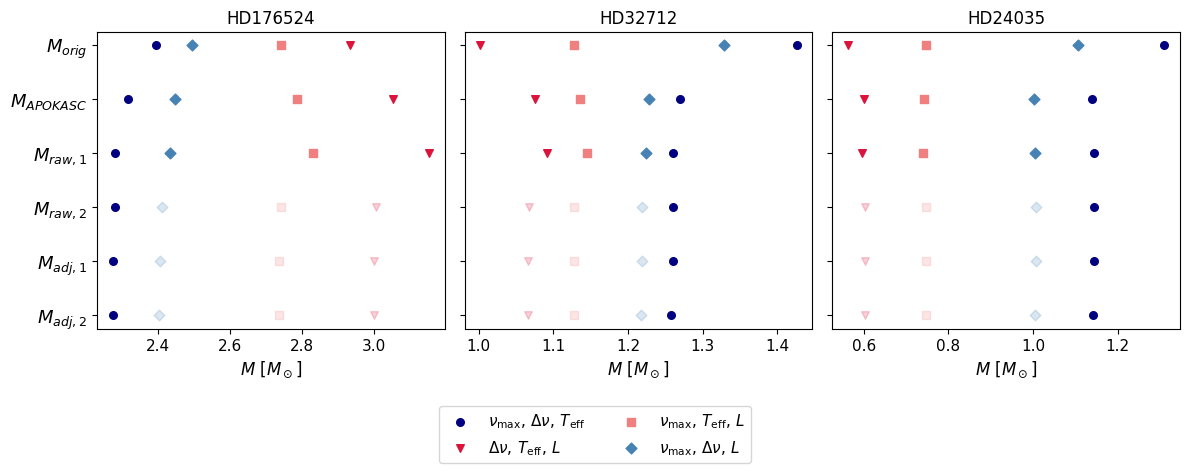

In [58]:
fts=13
methods = ['orig', 'apo', 'raw1','raw2','adj1','adj2']
x_labels = ['$M_{orig}$', '$M_{APOKASC}$', '$M_{raw,1}$', '$M_{raw,2}$','$M_{adj,1}$','$M_{adj,2}$']
colors=['navy','crimson','lightcoral','steelblue']
styles = {
    1: {'color': colors[0], 'marker': 'o', 'label': r'$\nu_\mathrm{max},\, \Delta \nu,\, T_\mathrm{eff}$'},
    2: {'color': colors[1], 'marker': 'v', 'label': r'$\Delta \nu,\, T_\mathrm{eff},\, L$'},
    3: {'color': colors[2], 'marker': 's', 'label': r'$\nu_\mathrm{max},\, T_\mathrm{eff},\, L$'},
    4: {'color': colors[3], 'marker': 'D', 'label': r'$\nu_\mathrm{max},\, \Delta \nu,\, L$'}
}

fig,ax=plt.subplots(1,3, figsize=(12,4),sharey=True)
ax=ax.flatten()

for i in range(3):
    ax[i].invert_yaxis()        

    df=data_dict[fname[i]]
    for eq in df['equation'].unique():
        eq_row = df[df['equation'] == eq]
        
        y_full = [eq_row[m].values[0] for m in methods[:3]]
        y_faded = [eq_row[m].values[0] for m in methods[3:]]
        
        ax[i].scatter(y_full, x_labels[:3], 
                    marker=styles[eq]['marker'], 
                    color=styles[eq]['color'],
                    label=styles[eq]['label'], 
                    s=30)
        
        a = 1.0 if eq == 1 else 0.2
        
        ax[i].scatter(y_faded, x_labels[3:], 
                    marker=styles[eq]['marker'], 
                    color=styles[eq]['color'],
                    alpha=a, 
                    s=30)

        ax[i].set_title(f'HD{fname[i]}')
        ax[i].set_xlabel(r'$M~[M_\odot]$', fontsize=12)
        ax[i].tick_params(axis='x', labelsize=fts-2)
    
        if i == 0:
            ax[i].tick_params(axis='y', labelsize=fts)

handles, labels = ax[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))

fig.legend(by_label.values(), by_label.keys(), 
           loc='center', 
           bbox_to_anchor=(0.5, -0.1), 
           ncol=2, 
           fontsize=fts-2,
           frameon=True)

plt.savefig('methods_masses.png', format='png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

## HD176524

In [61]:
fname='176524'

df=pd.read_csv(f'HD{fname}_masses.csv')
df

,equation,orig,e_orig,apo,e_apo,raw1,e_raw1,raw2,e_raw2,adj1,e_adj1,adj2,e_adj2
0,1,2.395020,0.321289,2.318848,0.320251,2.282227,0.315186,2.282599,0.315245,2.278113,0.314626,2.276367,0.314392
1,2,2.931641,0.481689,3.052246,0.503906,3.151367,0.520264,3.004532,0.496029,2.998629,0.495054,2.998535,0.495056
2,3,2.740723,0.297180,2.785156,0.302002,2.830078,0.306885,2.741618,0.297281,2.736231,0.296697,2.735352,0.296631
3,4,2.494141,0.261414,2.449707,0.262878,2.434082,0.261230,2.411412,0.258769,2.406674,0.258261,2.405273,0.258118


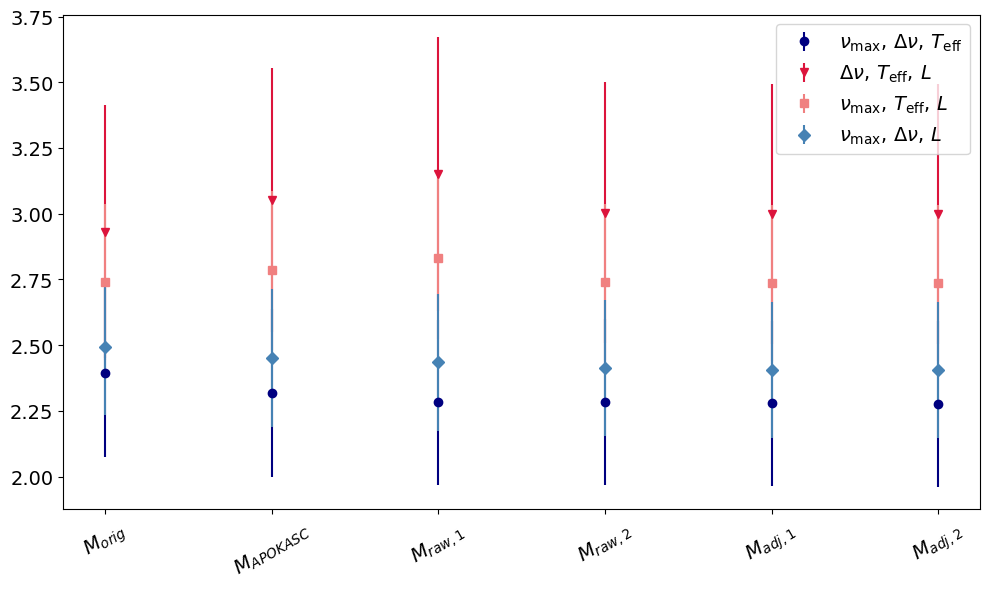

In [64]:
fts=14
methods = ['orig', 'apo', 'raw1', 'raw2', 'adj1', 'adj2']
x_labels = ['$M_{orig}$', '$M_{APOKASC}$', '$M_{raw,1}$', '$M_{raw,2}$', '$M_{adj,1}$', '$M_{adj,2}$']

styles = {
    1: {'color': 'navy', 'marker': 'o', 'label': r'$\nu_\mathrm{max},\, \Delta \nu,\, T_\mathrm{eff}$'},
    2: {'color': 'crimson', 'marker': 'v', 'label': r'$\Delta \nu,\, T_\mathrm{eff},\, L$'},
    3: {'color': 'lightcoral', 'marker': 's', 'label': r'$\nu_\mathrm{max},\, T_\mathrm{eff},\, L$'},
    4: {'color': 'steelblue', 'marker': 'D', 'label': r'$\nu_\mathrm{max},\, \Delta \nu,\, L$'}
}

plt.figure(figsize=(10, 6))

for eq in df['equation'].unique():
    eq_row = df[df['equation'] == eq]
    
    y_values = [eq_row[m].values[0] for m in methods]
    y_errors = [eq_row[f'e_{m}'].values[0] for m in methods]
    
    plt.errorbar(x_labels, y_values, yerr=y_errors, 
                 fmt=styles[eq]['marker'], 
                 color=styles[eq]['color'],
                 label=styles[eq]['label'],
                 capsize=0,             
                 ecolor=styles[eq]['color'],    
                 linestyle='None')      

plt.xticks(rotation=30, fontsize=fts)
plt.yticks(fontsize=fts)
plt.legend(fontsize=fts)

plt.tight_layout()
plt.show()

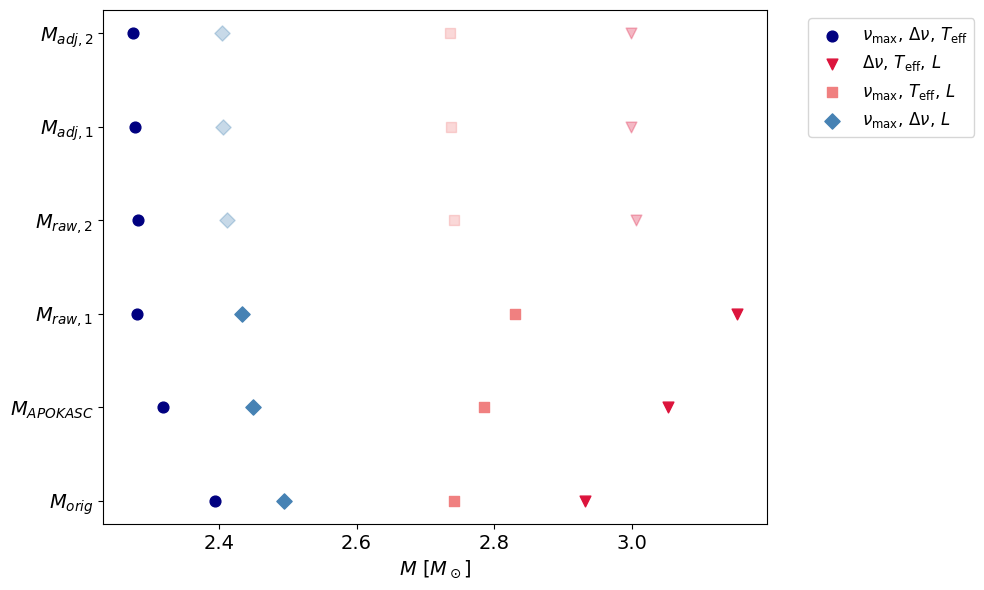

In [65]:
plt.figure(figsize=(10, 6))

for eq in df['equation'].unique():
    eq_row = df[df['equation'] == eq]
    
    y_full = [eq_row[m].values[0] for m in methods[:3]]
    y_faded = [eq_row[m].values[0] for m in methods[3:]]
    
    plt.scatter(y_full, x_labels[:3], 
                marker=styles[eq]['marker'], 
                color=styles[eq]['color'],
                label=styles[eq]['label'], 
                s=60)
    
    a = 1.0 if eq == 1 else 0.3
    
    plt.scatter(y_faded, x_labels[3:], 
                marker=styles[eq]['marker'], 
                color=styles[eq]['color'],
                alpha=a, 
                s=60)

plt.xlabel(r'$M~[M_\odot]$', fontsize=fts)
plt.yticks(fontsize=fts)
plt.xticks(fontsize=fts)
plt.legend(fontsize=fts - 2, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## HD24035

In [66]:
fname='24035'

df=pd.read_csv(f'HD{fname}_masses.csv')
df

,equation,orig,e_orig,apo,e_apo,raw1,e_raw1,raw2,e_raw2,adj1,e_adj1,adj2,e_adj2
0,1,1.309326,0.091476,1.138428,0.093475,1.142822,0.093842,1.143791,0.093916,1.144366,0.093963,1.141602,0.093750
1,2,0.563232,0.081711,0.600586,0.088074,0.595825,0.087387,0.603415,0.088489,0.603719,0.088533,0.603638,0.088547
2,3,0.746216,0.067230,0.743286,0.066971,0.740356,0.066711,0.746788,0.067286,0.747163,0.067320,0.746582,0.067261
3,4,1.106201,0.057320,1.001709,0.060081,1.003418,0.060181,1.006428,0.060365,1.006934,0.060395,1.005127,0.060287


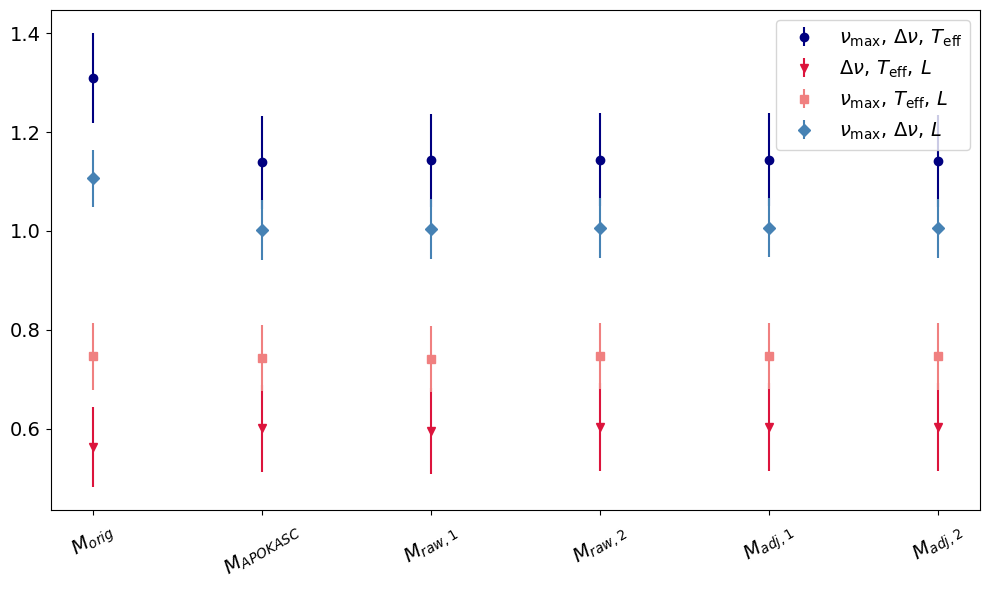

In [67]:
fts=14
methods = ['orig', 'apo', 'raw1', 'raw2', 'adj1', 'adj2']
x_labels = ['$M_{orig}$', '$M_{APOKASC}$', '$M_{raw,1}$', '$M_{raw,2}$', '$M_{adj,1}$', '$M_{adj,2}$']

styles = {
    1: {'color': 'navy', 'marker': 'o', 'label': r'$\nu_\mathrm{max},\, \Delta \nu,\, T_\mathrm{eff}$'},
    2: {'color': 'crimson', 'marker': 'v', 'label': r'$\Delta \nu,\, T_\mathrm{eff},\, L$'},
    3: {'color': 'lightcoral', 'marker': 's', 'label': r'$\nu_\mathrm{max},\, T_\mathrm{eff},\, L$'},
    4: {'color': 'steelblue', 'marker': 'D', 'label': r'$\nu_\mathrm{max},\, \Delta \nu,\, L$'}
}

plt.figure(figsize=(10, 6))

for eq in df['equation'].unique():
    eq_row = df[df['equation'] == eq]
    
    y_values = [eq_row[m].values[0] for m in methods]
    y_errors = [eq_row[f'e_{m}'].values[0] for m in methods]
    
    plt.errorbar(x_labels, y_values, yerr=y_errors, 
                 fmt=styles[eq]['marker'], 
                 color=styles[eq]['color'],
                 label=styles[eq]['label'],
                 capsize=0,             
                 ecolor=styles[eq]['color'],    
                 linestyle='None')      

plt.xticks(rotation=30, fontsize=fts)
plt.yticks(fontsize=fts)
plt.legend(fontsize=fts)

plt.tight_layout()
plt.show()

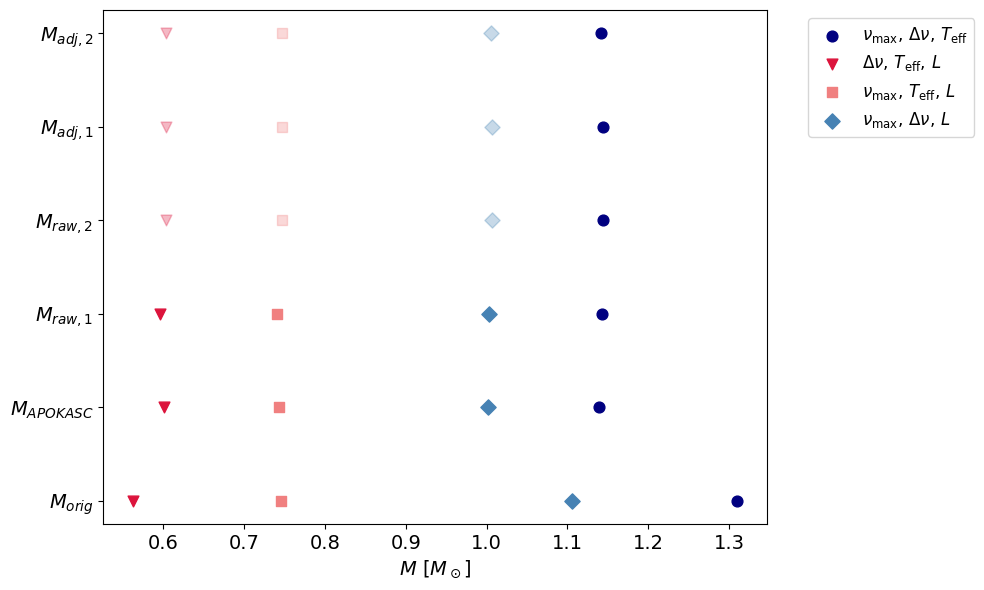

In [68]:
plt.figure(figsize=(10, 6))

for eq in df['equation'].unique():
    eq_row = df[df['equation'] == eq]
    
    y_full = [eq_row[m].values[0] for m in methods[:3]]
    y_faded = [eq_row[m].values[0] for m in methods[3:]]
    
    plt.scatter(y_full, x_labels[:3], 
                marker=styles[eq]['marker'], 
                color=styles[eq]['color'],
                label=styles[eq]['label'], 
                s=60)
    
    a = 1.0 if eq == 1 else 0.3
    
    plt.scatter(y_faded, x_labels[3:], 
                marker=styles[eq]['marker'], 
                color=styles[eq]['color'],
                alpha=a, 
                s=60)

plt.xlabel(r'$M~[M_\odot]$', fontsize=fts)
plt.yticks(fontsize=fts)
plt.xticks(fontsize=fts)
plt.legend(fontsize=fts - 2, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## HD32712

In [69]:
fname='32712'

df=pd.read_csv(f'HD{fname}_masses.csv')
df

,equation,orig,e_orig,apo,e_apo,raw1,e_raw1,raw2,e_raw2,adj1,e_adj1,adj2,e_adj2
0,1,1.426025,0.070587,1.269531,0.087234,1.259766,0.086548,1.260220,0.086595,1.259838,0.086568,1.257812,0.086441
1,2,1.002197,0.140381,1.074707,0.152710,1.091797,0.155151,1.066825,0.151590,1.066502,0.151544,1.066406,0.151550
2,3,1.127197,0.094101,1.136230,0.094849,1.145020,0.095596,1.127897,0.094153,1.127555,0.094124,1.126953,0.094070
3,4,1.328857,0.039749,1.228027,0.055023,1.224121,0.054855,1.219021,0.054620,1.218651,0.054603,1.217041,0.054535


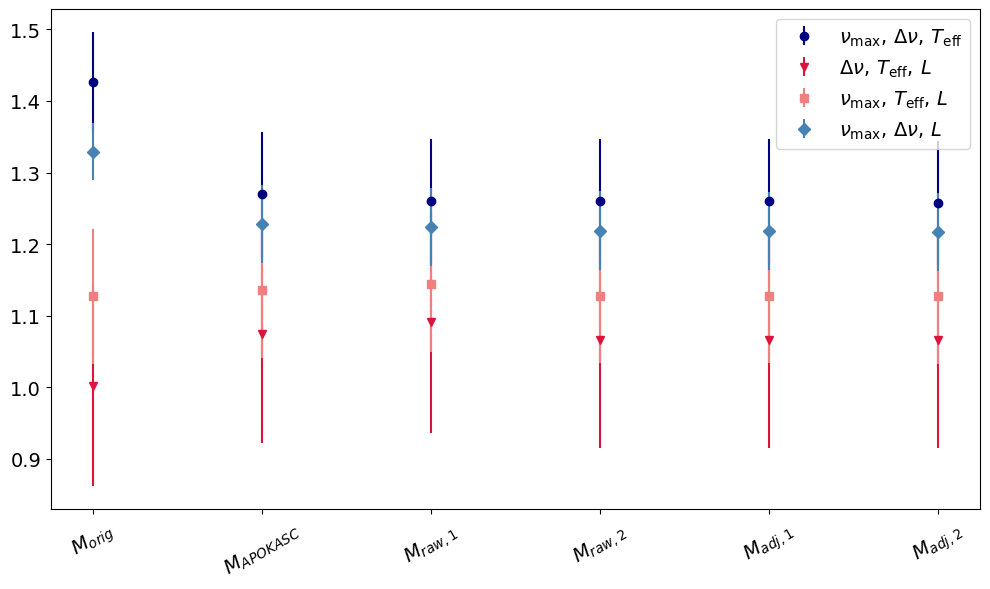

In [70]:
fts=14
methods = ['orig', 'apo', 'raw1', 'raw2', 'adj1', 'adj2']
x_labels = ['$M_{orig}$', '$M_{APOKASC}$', '$M_{raw,1}$', '$M_{raw,2}$', '$M_{adj,1}$', '$M_{adj,2}$']

styles = {
    1: {'color': 'navy', 'marker': 'o', 'label': r'$\nu_\mathrm{max},\, \Delta \nu,\, T_\mathrm{eff}$'},
    2: {'color': 'crimson', 'marker': 'v', 'label': r'$\Delta \nu,\, T_\mathrm{eff},\, L$'},
    3: {'color': 'lightcoral', 'marker': 's', 'label': r'$\nu_\mathrm{max},\, T_\mathrm{eff},\, L$'},
    4: {'color': 'steelblue', 'marker': 'D', 'label': r'$\nu_\mathrm{max},\, \Delta \nu,\, L$'}
}

plt.figure(figsize=(10, 6))

for eq in df['equation'].unique():
    eq_row = df[df['equation'] == eq]
    
    y_values = [eq_row[m].values[0] for m in methods]
    y_errors = [eq_row[f'e_{m}'].values[0] for m in methods]
    
    plt.errorbar(x_labels, y_values, yerr=y_errors, 
                 fmt=styles[eq]['marker'], 
                 color=styles[eq]['color'],
                 label=styles[eq]['label'],
                 capsize=0,             
                 ecolor=styles[eq]['color'],    
                 linestyle='None')      

plt.xticks(rotation=30, fontsize=fts)
plt.yticks(fontsize=fts)
plt.legend(fontsize=fts)

plt.tight_layout()
plt.show()

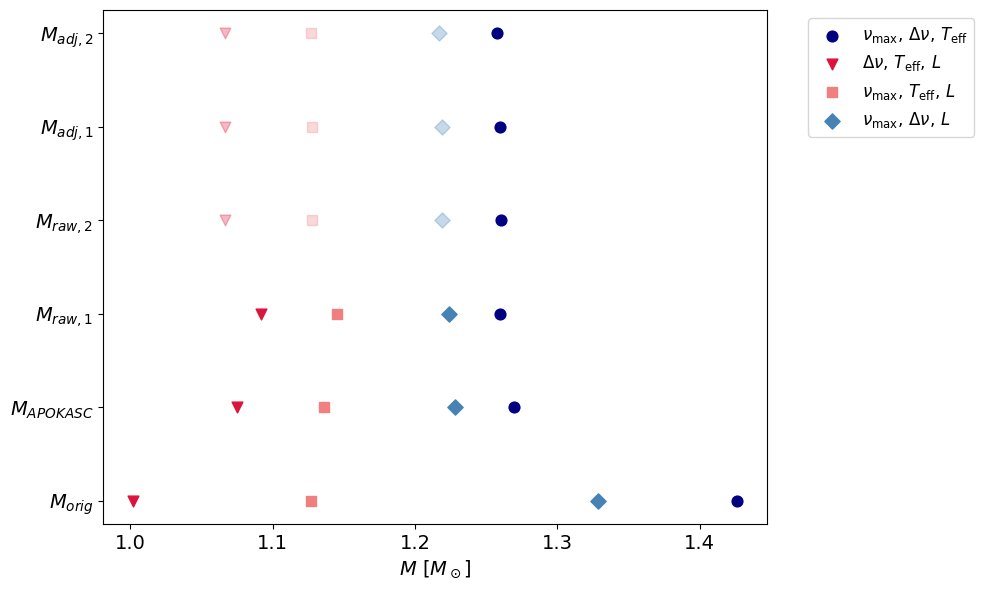

In [71]:
plt.figure(figsize=(10, 6))

for eq in df['equation'].unique():
    eq_row = df[df['equation'] == eq]
    
    y_full = [eq_row[m].values[0] for m in methods[:3]]
    y_faded = [eq_row[m].values[0] for m in methods[3:]]
    
    plt.scatter(y_full, x_labels[:3], 
                marker=styles[eq]['marker'], 
                color=styles[eq]['color'],
                label=styles[eq]['label'], 
                s=60)
    
    a = 1.0 if eq == 1 else 0.3
    
    plt.scatter(y_faded, x_labels[3:], 
                marker=styles[eq]['marker'], 
                color=styles[eq]['color'],
                alpha=a, 
                s=60)

plt.xlabel(r'$M~[M_\odot]$', fontsize=fts)
plt.yticks(fontsize=fts)
plt.xticks(fontsize=fts)
plt.legend(fontsize=fts - 2, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()